# Battle Outcome Model — Casualty Prediction

This notebook trains regression models to predict:
- **Section A:** `att_cas_frac` and `def_cas_frac` — casualties as a fraction of pre-battle strength (~654 battles)
- **Section B:** `attacker_carty` and `defender_carty` — raw artillery losses (~230 battles, subset with data)

Only pre-battle features are used.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from tqdm import tqdm
import joblib

## 1. Load Data & Select Features

In [2]:
df = pd.read_excel('History_Battles.xlsx')

keep_cols = [
    'post1', 'surpa', 'morala', 'logsa', 'momnta', 'techa', 'inita',
    'attacker_str', 'attacker_cav', 'attacker_arty',
    'defender_str', 'defender_cav', 'defender_arty',
    'terra1', 'terra2', 'attacker_pri1', 'defender_pri1',
    'att_comm_quality', 'def_comm_quality',
    'wina', 'attacker_cas', 'defender_cas', 'attacker_carty', 'defender_carty'
]

df = df[keep_cols]
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (660, 24)


,post1,surpa,morala,logsa,momnta,techa,inita,attacker_str,attacker_cav,attacker_arty,...,terra2,attacker_pri1,defender_pri1,att_comm_quality,def_comm_quality,wina,attacker_cas,defender_cas,attacker_carty,defender_carty
0,HD,0.0,0.0,0.0,1.0,0.0,1.0,11500.0,1500.0,8.0,...,B,FF,DO,0.0,1.0000,0,4000.0,1000.0,8.0,0.0
1,HD,0.0,0.0,0.0,1.0,0.0,1.0,40000.0,7500.0,12.0,...,M,FF,DO,1.0,0.0000,1,400.0,5000.0,0.0,10.0
2,HD,0.0,0.0,0.0,NaN,0.0,0.0,20000.0,4000.0,8.0,...,M,FF,DD,0.5,0.0000,1,5000.0,5800.0,0.0,20.0
3,PD,NaN,0.0,0.0,0.0,0.0,NaN,8500.0,2500.0,9.0,...,M,FF,DO,0.0,0.6667,0,3000.0,1000.0,9.0,0.0
4,HD,0.0,1.0,0.0,1.0,0.0,0.0,17000.0,7000.0,12.0,...,M,FF,DO,0.5,0.0000,1,2000.0,7000.0,0.0,22.0


## 2. Missing Value Analysis

In [3]:
print(df.isna().sum())

post1                 2
surpa                15
morala               45
logsa                58
momnta               39
techa                41
inita                59
attacker_str          1
attacker_cav         78
attacker_arty       101
defender_str          1
defender_cav         76
defender_arty       119
terra1               16
terra2               20
attacker_pri1         8
defender_pri1        37
att_comm_quality      0
def_comm_quality      0
wina                  0
attacker_cas          6
defender_cas          4
attacker_carty      426
defender_carty      399
dtype: int64


In [4]:
# Impute neutral-value columns with 0
cols_impute_zero = ['surpa', 'morala', 'logsa', 'momnta', 'techa', 'inita']
df[cols_impute_zero] = df[cols_impute_zero].fillna(0)

# Terrain: fill missing with 'O' (Other/not available)
df['terra1'] = df['terra1'].fillna('O')
df['terra2'] = df['terra2'].fillna('O')

print('NaNs after manual imputation:')
print(df.isna().sum())

NaNs after manual imputation:
post1                 2
surpa                 0
morala                0
logsa                 0
momnta                0
techa                 0
inita                 0
attacker_str          1
attacker_cav         78
attacker_arty       101
defender_str          1
defender_cav         76
defender_arty       119
terra1                0
terra2                0
attacker_pri1         8
defender_pri1        37
att_comm_quality      0
def_comm_quality      0
wina                  0
attacker_cas          6
defender_cas          4
attacker_carty      426
defender_carty      399
dtype: int64


## 3. Create Target Fractions

We predict casualties as a **fraction of pre-battle strength** (0-1 scale) rather than raw numbers.
This normalises across battle sizes — losing 5,000 men means very different things for an army of 10,000 vs 100,000.

In the simulation, we will multiply the predicted fraction by the army's actual strength to get raw casualties.

In [5]:
df['att_cas_frac'] = df['attacker_cas'] / df['attacker_str']
df['def_cas_frac'] = df['defender_cas'] / df['defender_str']

# Clip to [0, 1] — a few records have casualties slightly exceeding reported strength
df['att_cas_frac'] = df['att_cas_frac'].clip(0, 1)
df['def_cas_frac'] = df['def_cas_frac'].clip(0, 1)

print('Attacker casualty fraction:')
print(df['att_cas_frac'].describe())
print('\nDefender casualty fraction:')
print(df['def_cas_frac'].describe())

Attacker casualty fraction:
count    654.000000
mean       0.112134
std        0.128328
min        0.001224
25%        0.025429
50%        0.066352
75%        0.158023
max        1.000000
Name: att_cas_frac, dtype: float64

Defender casualty fraction:
count    656.000000
mean       0.208569
std        0.225725
min        0.000333
25%        0.053868
50%        0.122038
75%        0.290667
max        1.000000
Name: def_cas_frac, dtype: float64


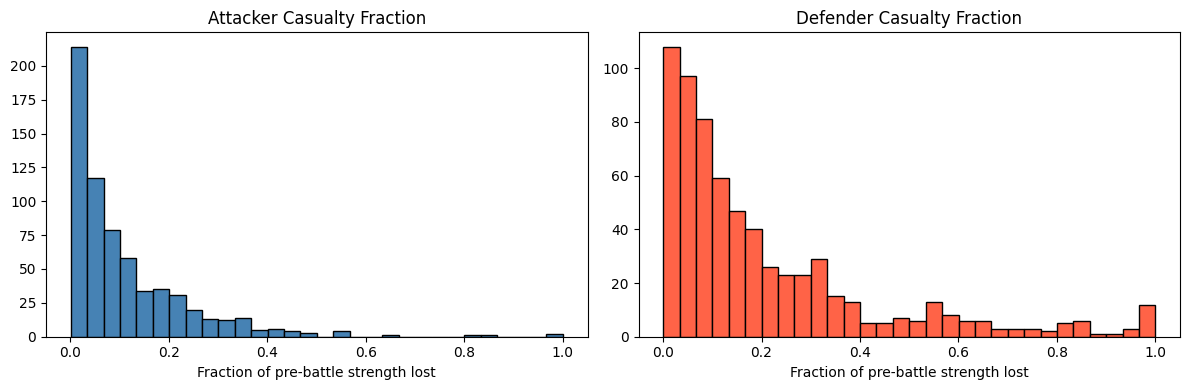

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['att_cas_frac'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Attacker Casualty Fraction')
axes[0].set_xlabel('Fraction of pre-battle strength lost')
axes[1].hist(df['def_cas_frac'].dropna(), bins=30, color='tomato', edgecolor='black')
axes[1].set_title('Defender Casualty Fraction')
axes[1].set_xlabel('Fraction of pre-battle strength lost')
plt.tight_layout()
plt.show()

## 4. Preprocessing Pipeline

Same feature set and encoding strategy as the `wina` classification notebook.
Commander quality is a pre-computed float — no `TargetEncoder` needed.

In [7]:
# Continuous numerical features (army sizes — scaled)
num_feat      = ['attacker_str', 'attacker_cav', 'attacker_arty',
                 'defender_str', 'defender_cav', 'defender_arty']
low_card_feat = ['surpa', 'morala', 'logsa', 'momnta', 'techa', 'inita',
                 'post1', 'terra1', 'terra2', 'attacker_pri1', 'defender_pri1']
# Commander quality — already in [0, 1], passed through unchanged
quality_feat  = ['att_comm_quality', 'def_comm_quality']
feature_cols  = num_feat + low_card_feat + quality_feat

num_transf = Pipeline(steps=[
    ('scaler',  StandardScaler()),
    ('imputer', SimpleImputer(strategy='median'))
])
low_card_transf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

def make_preprocessor():
    """Returns a fresh preprocessor — needed since each model gets its own fitted pipeline."""
    return ColumnTransformer(
        transformers=[
            ('num',      num_transf,      num_feat),
            ('low_card', low_card_transf, low_card_feat),
            ('quality',  'passthrough',   quality_feat),
        ],
        remainder='drop'
    )

## 5. Training Helper

Shared function used for both casualty fractions (Section A) and artillery losses (Section B).

In [8]:
param_spaces_reg = {
    'Random Forest': {
        'n_estimators':      (10, 300),
        'max_depth':         (3, 12),
        'min_samples_split': (2, 10),
        'min_samples_leaf':  (4, 10),
        'max_features':      ['sqrt', 'log2'],
        'bootstrap':         [True, False]
    },
    'XGBoost': {
        'n_estimators':     (50, 1000),
        'learning_rate':    (0.001, 0.3, 'log-uniform'),
        'max_depth':        (3, 8),
        'min_child_weight': (1, 5),
        'subsample':        (0.5, 0.9),
        'colsample_bytree': (0.5, 0.9),
        'gamma':            (0, 5),
        'reg_alpha':        (0.0, 1.0),
        'reg_lambda':       (0.5, 5.0)
    }
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)


def train_regression_model(df_subset, target_col, label):
    """
    Trains RF + XGBoost on df_subset[target_col] using feature_cols.
    Returns (fitted_pipeline, fitted_voting_regressor).
    """
    X = df_subset[feature_cols]
    y = df_subset[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline(steps=[('preprocessor', make_preprocessor())])
    X_train_proc = pipeline.fit_transform(X_train, y_train)
    X_test_proc  = pipeline.transform(X_test)

    # Linear Regression baseline
    lr = LinearRegression().fit(X_train_proc, y_train)
    lr_pred = lr.predict(X_test_proc)
    print(f'\n--- {label} ---')
    print(f'  Linear baseline  MAE={mean_absolute_error(y_test, lr_pred):.4f}  '
          f'R2={r2_score(y_test, lr_pred):.4f}')

    # Bayesian search for RF and XGBoost
    best_models = {}
    results = []

    model_constructors = {
        'Random Forest': RandomForestRegressor(random_state=42),
        'XGBoost':       XGBRegressor(random_state=42)
    }

    for name, model in tqdm(model_constructors.items(), desc=f'Optimising [{label}]'):
        opt = BayesSearchCV(
            model, param_spaces_reg[name],
            n_iter=40, cv=kf,
            scoring='neg_mean_absolute_error',
            n_jobs=2, random_state=42
        )
        opt.fit(X_train_proc, y_train)
        best_models[name] = opt.best_estimator_

        y_pred = opt.predict(X_test_proc)
        mae    = mean_absolute_error(y_test, y_pred)
        rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
        r2     = r2_score(y_test, y_pred)
        cv_mae = -cross_val_score(opt.best_estimator_, X_train_proc, y_train,
                                  cv=kf, scoring='neg_mean_absolute_error').mean()
        results.append([name, mae, rmse, r2, cv_mae])

    results_df = pd.DataFrame(
        results, columns=['Model', 'MAE (test)', 'RMSE (test)', 'R2 (test)', 'MAE (CV)']
    )
    print(results_df.to_string(index=False))

    # Voting ensemble
    voting = VotingRegressor([
        ('rf',  best_models['Random Forest']),
        ('xgb', best_models['XGBoost'])
    ])
    voting.fit(X_train_proc, y_train)
    v_pred = voting.predict(X_test_proc)
    print(f'  Voting ensemble  MAE={mean_absolute_error(y_test, v_pred):.4f}  '
          f'R2={r2_score(y_test, v_pred):.4f}')

    # Actual vs predicted plot
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, v_pred, alpha=0.5, edgecolors='k', s=20)
    lims = [min(y_test.min(), v_pred.min()), max(y_test.max(), v_pred.max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted — {label}')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pipeline, voting, best_models

## 6. Section A — Casualty Fractions

Trained on all battles with recorded casualties (~654 battles after filtering).

In [9]:
df_cas = df.dropna(subset=['att_cas_frac', 'def_cas_frac']).copy()
print(f'Battles with casualty data: {len(df_cas)}')

Battles with casualty data: 654



--- Attacker Casualty Fraction (log-transformed) ---
  Linear baseline  MAE=0.0718  R2=0.1121


Optimising [Attacker Casualty Fraction (log-transformed)]: 100%|██████████| 2/2 [05:05<00:00, 152.73s/it]


        Model  MAE (test)  RMSE (test)  R2 (test)  MAE (CV)
Random Forest    0.064477     0.095439   0.205999  0.057110
      XGBoost    0.067093     0.095720   0.201319  0.056423
  Voting ensemble  MAE=0.0653  R2=0.2167


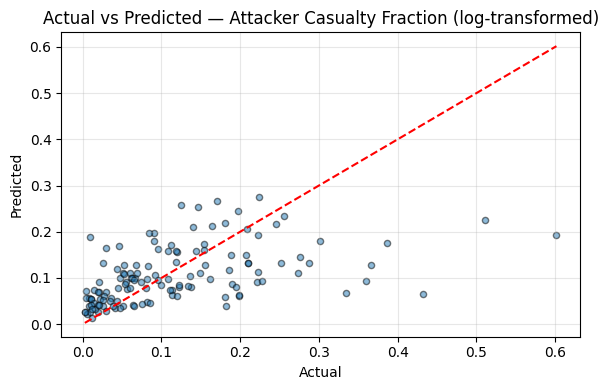

In [10]:
# Log-transform the targets to handle right-skewed distribution
# np.log1p handles zeros safely (log(1+x))
df_cas['att_cas_frac_log'] = np.log1p(df_cas['att_cas_frac'])
df_cas['def_cas_frac_log'] = np.log1p(df_cas['def_cas_frac'])

pipeline_att, model_att, best_models_att = train_regression_model(
    df_cas, 'att_cas_frac_log', 'Attacker Casualty Fraction (log-transformed)'
)


--- Defender Casualty Fraction (original scale) ---
  Linear baseline  MAE=0.1542  R2=0.1304


Optimising [Defender Casualty Fraction (original scale)]: 100%|██████████| 2/2 [04:50<00:00, 145.46s/it]


        Model  MAE (test)  RMSE (test)  R2 (test)  MAE (CV)
Random Forest    0.138251     0.200924   0.281567  0.130981
      XGBoost    0.139313     0.203962   0.259679  0.130297
  Voting ensemble  MAE=0.1381  R2=0.2792


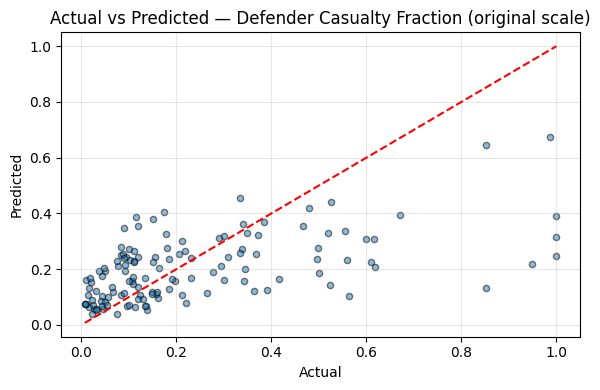

In [11]:
pipeline_def, model_def, best_models_def = train_regression_model(
    df_cas, 'def_cas_frac', 'Defender Casualty Fraction (original scale)'
)

## 7. Section B — Artillery Losses

Trained only on battles that have artillery loss data recorded.
Predicted as raw number of guns lost.

In [12]:
df_att_carty = df.dropna(subset=['attacker_carty']).copy()
df_def_carty = df.dropna(subset=['defender_carty']).copy()
print(f'Battles with attacker_carty: {len(df_att_carty)}')
print(f'Battles with defender_carty: {len(df_def_carty)}')

Battles with attacker_carty: 234
Battles with defender_carty: 261


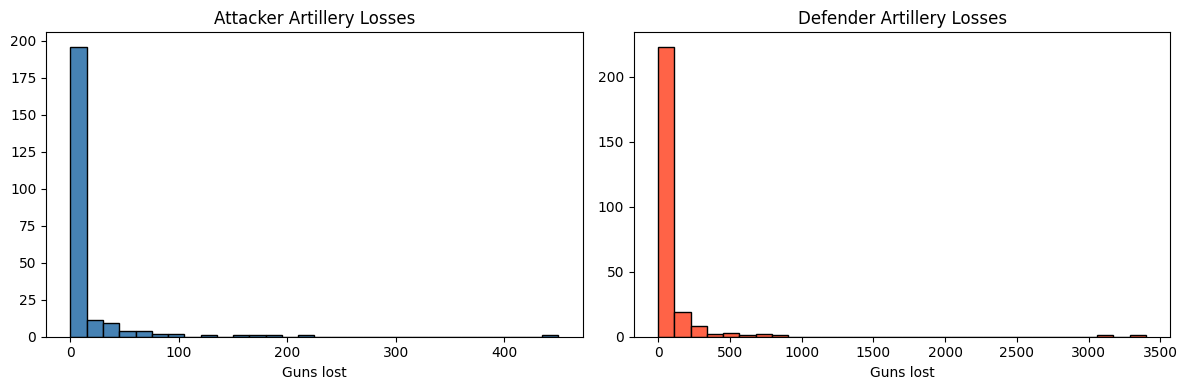

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_att_carty['attacker_carty'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Attacker Artillery Losses')
axes[0].set_xlabel('Guns lost')
axes[1].hist(df_def_carty['defender_carty'], bins=30, color='tomato', edgecolor='black')
axes[1].set_title('Defender Artillery Losses')
axes[1].set_xlabel('Guns lost')
plt.tight_layout()
plt.show()


--- Attacker Artillery Losses ---
  Linear baseline  MAE=26.2592  R2=0.3117


Optimising [Attacker Artillery Losses]: 100%|██████████| 2/2 [04:26<00:00, 133.48s/it]


        Model  MAE (test)  RMSE (test)  R2 (test)  MAE (CV)
Random Forest   22.034363    71.666273   0.058653  9.799931
      XGBoost   23.645832    73.642286   0.006027  9.082176
  Voting ensemble  MAE=22.7160  R2=0.0425


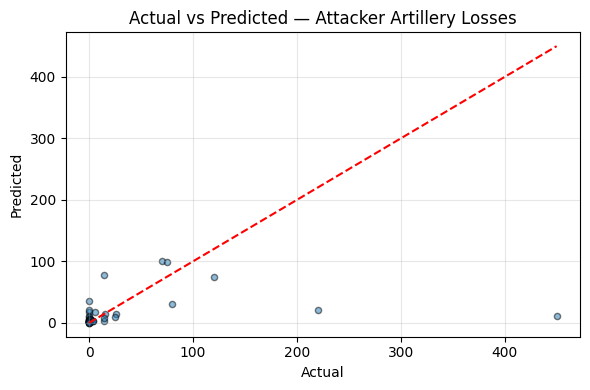

In [14]:
pipeline_att_carty, model_att_carty, best_models_att_carty = train_regression_model(
    df_att_carty, 'attacker_carty', 'Attacker Artillery Losses'
)


--- Defender Artillery Losses ---
  Linear baseline  MAE=103.4950  R2=0.1719


Optimising [Defender Artillery Losses]: 100%|██████████| 2/2 [04:25<00:00, 132.69s/it]


        Model  MAE (test)  RMSE (test)  R2 (test)  MAE (CV)
Random Forest   85.492604   364.850562   0.283990 61.065814
      XGBoost   83.131651   367.938571   0.271818 58.596975
  Voting ensemble  MAE=84.2308  R2=0.2782


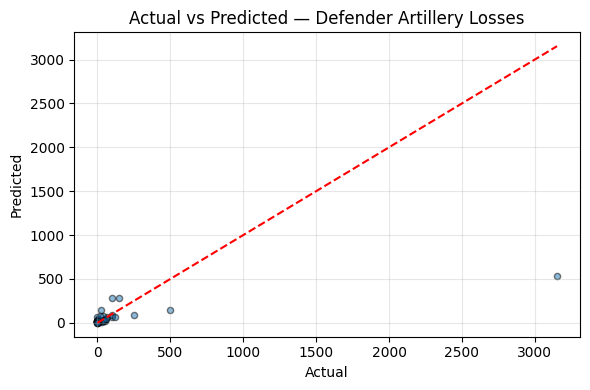

In [15]:
pipeline_def_carty, model_def_carty, best_models_def_carty = train_regression_model(
    df_def_carty, 'defender_carty', 'Defender Artillery Losses'
)

## 8. Save Models

All four models bundled into a single file.
Load once at simulation startup, call `predict_casualties()` on each battle.

In [ ]:
casualties_bundle = {
    'att_cas':   {'pipeline': pipeline_att, 'model': model_att, 'log_transform': True},
    'def_cas':   {'pipeline': pipeline_def, 'model': best_models_def['Random Forest'], 'log_transform': False},
    'att_carty': {'pipeline': pipeline_att_carty, 'model': best_models_att_carty['Random Forest'], 'log_transform': False},
    'def_carty': {'pipeline': pipeline_def_carty, 'model': best_models_def_carty['XGBoost'], 'log_transform': False},
}

joblib.dump(casualties_bundle, 'battle_outcome_casualties.pkl')
print('Casualty models saved.')

Casualty models saved.
